# 03 - Temporal VAE

Adds time context to the ConvVAE. Each training example is a run of 30 consecutive days. The CNN encodes each day, a one-direction LSTM reads the days in order, and the latent mean of day t comes from the day's own features concatenated with the LSTM state. Day t never sees days after t, which keeps the model usable for early warning.

Loss = reconstruction + beta * KL + lambda * smoothness, where smoothness is the squared change of the latent mean between consecutive days. This is the first stage of the temporal regularity idea in Nie et al. (2026). The second stage replaces the smoothness term with regime probabilities and a transition penalty.

Pipeline: 30 days of scalograms -> CNN per day -> causal LSTM -> latent mean per day + daily price level -> GMM -> regime

<d.benavidess@uniandes.edu.co>

In [1]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch

import numpy as np
import pandas as pd

import altair as alt
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

plt.rcParams['font.family'] = 'Arial'
alt.data_transformers.enable('vegafusion')

from src.data import load_scalograms, load_context, chronological_split, ScalogramSequenceDataset
from src.models.temporal_vae import TemporalVAE
from src.training import set_seed, train, save_run
from src.clustering import with_level, assign_regimes, summary_metrics, regime_profile, save_regimes
from src.plots import loss_curves, selection_chart, tsne_chart, regime_timeline, plot_reconstructions

In [2]:
import warnings
warnings.filterwarnings("ignore")

## 0. Experiment Run

In [3]:
# Update the run name to reflect the current experiment
# Update 1. Configuration / CONFIG n_regimes
RUN_NAME = "run01_k8"
n_regimes = 8

## 1. Configuration

`rnn_type` accepts "lstm" or "gru". `lam` is the weight of the smoothness term. The term measures the day-to-day change of each latent dimension relative to its spread, so it is about 1 minus the lag-1 autocorrelation (0 means perfectly smooth) and does not drop when the latent space shrinks. With the reconstruction term near 1,000, `lam` = 100 gives the smoothness term a real but secondary weight. If the latents become almost constant, lower it; if regimes still flicker day to day, raise it.

In [4]:
SCALOGRAM_DIR = Path("../data/processed/scalograms")
DATA_DIR = Path("../data/processed")
MODEL_DIR = Path("../models/temporal_vae") / RUN_NAME
FIGURE_DIR = Path("../figures/temporal_vae") / RUN_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "z_dim": 16,
    "filters": [32, 64, 128],
    "proj_dim": 128,
    "rnn_type": "lstm",
    "rnn_hidden": 64,
    "seq_len": 30,
    "stride": 7,
    "beta": 1.0,
    "lam": 100.0,
    "kl_warmup_epochs": 0,
    "lr": 1e-3,
    "batch_size": 16,
    "epochs": 30,
    "train_ratio": 0.6,
    "val_ratio": 0.2,
    "n_regimes": n_regimes,
    "k_range": [2, 3, 4, 5, 6, 7, 8],
    "seed": 42,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(CONFIG["seed"])
print(f"Device: {DEVICE}")

Device: cpu


## 2. Data

In [5]:
images, metadata = load_scalograms(SCALOGRAM_DIR)
context = load_context(DATA_DIR, metadata)
train_idx, val_idx, test_idx = chronological_split(len(images), CONFIG["train_ratio"], CONFIG["val_ratio"])
split_dates = [context["date"].iloc[val_idx[0]], context["date"].iloc[test_idx[0]]]

IMG_C, IMG_H, IMG_W = images.shape[1:]
print(f"Scalograms: {images.shape}, range [{images.min():.3f}, {images.max():.3f}]")

t = PrettyTable(["Split", "Days", "From", "To"])
for name, idx in (("train", train_idx), ("val", val_idx), ("test", test_idx)):
    t.add_row([name, len(idx), context["date"].iloc[idx[0]].date(), context["date"].iloc[idx[-1]].date()])
print(t)

Scalograms: (9709, 1, 128, 24), range [0.000, 1.000]
+-------+------+------------+------------+
| Split | Days |    From    |     To     |
+-------+------+------------+------------+
| train | 5825 | 2000-01-01 | 2015-12-12 |
|  val  | 1942 | 2015-12-13 | 2021-04-06 |
|  test | 1942 | 2021-04-07 | 2026-07-31 |
+-------+------+------------+------------+


In [6]:
train_set = ScalogramSequenceDataset(images, train_idx, CONFIG["seq_len"], CONFIG["stride"])
val_set = ScalogramSequenceDataset(images, val_idx, CONFIG["seq_len"], CONFIG["stride"])
train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_set, batch_size=CONFIG["batch_size"], shuffle=False)
print(f"Sequences of {CONFIG['seq_len']} days: train {len(train_set)}, val {len(val_set)}")

Sequences of 30 days: train 828, val 274


## 3. Model

In [7]:
model = TemporalVAE(CONFIG["z_dim"], IMG_C, IMG_H, IMG_W, CONFIG["filters"],
                    CONFIG["proj_dim"], CONFIG["rnn_hidden"], CONFIG["rnn_type"]).to(DEVICE)

with torch.no_grad():
    sample = train_set[0][0].unsqueeze(0).to(DEVICE)
    out_shape = tuple(model(sample)[0].shape[1:])
assert out_shape == tuple(sample.shape[1:]), f"decoder output {out_shape} does not match input"

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input sequence: {tuple(sample.shape[1:])}")
print(f"Decoder output: {out_shape}")

Parameters: 1,132,705
Input sequence: (30, 1, 128, 24)
Decoder output: (30, 1, 128, 24)


## 4. Training

In [8]:
history = train(model, train_loader, val_loader, DEVICE, epochs=CONFIG["epochs"], lr=CONFIG["lr"],
                beta=CONFIG["beta"], kl_warmup_epochs=CONFIG["kl_warmup_epochs"],
                extra_loss_kwargs={"lam": CONFIG["lam"]})
save_run(MODEL_DIR, model, CONFIG, history)

Epoch   1/30  train: total=1092275.29  recon=1865.67  kl=1090369.48  smooth=0.40  val total=1464.34
Epoch   5/30  train: total=1006.74  recon=983.58  kl=10.54  smooth=0.13  val total=1050.15
Epoch  10/30  train: total=982.83  recon=968.33  kl=7.50  smooth=0.07  val total=1032.11
Epoch  15/30  train: total=976.51  recon=963.67  kl=6.69  smooth=0.06  val total=1024.38
Epoch  20/30  train: total=971.24  recon=959.29  kl=6.40  smooth=0.06  val total=1019.31
Epoch  25/30  train: total=970.55  recon=958.95  kl=6.32  smooth=0.05  val total=1016.00
Epoch  30/30  train: total=972.42  recon=960.53  kl=6.45  smooth=0.05  val total=1015.92


## 5. Loss curves

Posterior collapse check: if the KL curve drops close to zero, the encoder is ignoring the input. In that case try `beta` below 1 or set `kl_warmup_epochs` (for example 10). Active dimensions counts the latent dimensions whose mean actually varies across days.

In [9]:
loss_plot = loss_curves(history, components=("total", "recon", "kl", "smooth"))
loss_plot

alt.HConcatChart(...)

In [10]:
loss_plot.save(str(FIGURE_DIR / "loss_curves.png"), scale_factor=2.0)

## 6. Reconstructions

Eight consecutive days from the test period.

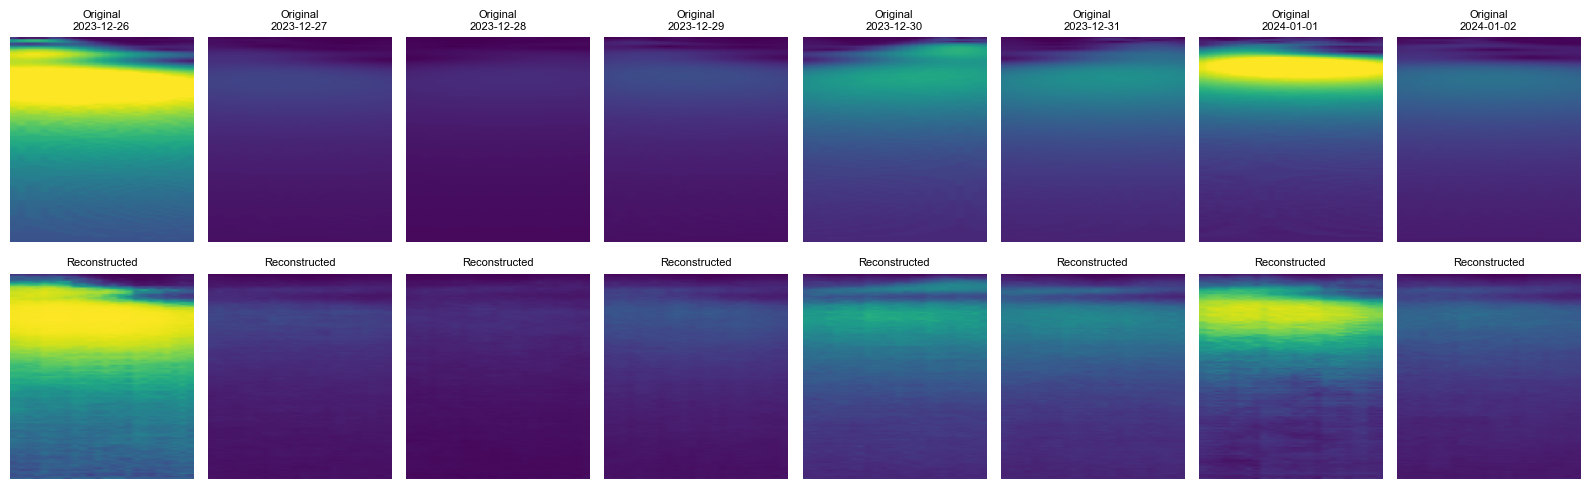

In [11]:
model.eval()
start = test_idx[len(test_idx) // 2]
seq = torch.from_numpy(images[start:start + CONFIG["seq_len"]]).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    recon = model(seq)[0][0].cpu().numpy()

show = np.arange(CONFIG["seq_len"] - 8, CONFIG["seq_len"])
fig = plot_reconstructions(images[start + show], recon[show], [str(d.date()) for d in context["date"].iloc[start + show]])
fig.savefig(FIGURE_DIR / "reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Latent vectors

Each day's vector is computed from that day and the 29 days before it, the same context the model saw in training.

In [12]:
latents = model.extract_latents(images, DEVICE, seq_len=CONFIG["seq_len"])

np.save(MODEL_DIR / "latents.npy", latents)
features = with_level(latents, metadata, train_idx)

active = int((latents.var(axis=0) > 0.01).sum())
print(f"Latent vectors: {latents.shape}")
print(f"Final train KL: {history[-1]['train_kl']:.2f}")
print(f"Active dimensions: {active} of {CONFIG['z_dim']}")
print(f"GMM features (latents + daily level): {features.shape}")

Latent vectors: (9709, 16)
Final train KL: 6.45
Active dimensions: 16 of 16
GMM features (latents + daily level): (9709, 18)


## 8. Regimes with a Gaussian mixture

The GMM uses the latent vector plus the daily price level (mean and standard deviation of the log real price, z-scored on training days), because the scalograms only carry the intraday shape. It is fitted on the training days only and then assigns every day. The number of regimes is the one with the lowest BIC unless `CONFIG["n_regimes"]` fixes it. Regimes are numbered by ascending mean real price, so regime 0 is always the cheapest and labels are comparable across models.

In [13]:
selection, K, labels, probs = assign_regimes(
    features, train_idx, context["precio_real_cop_kwh"].to_numpy(),
    k=CONFIG["n_regimes"], k_range=CONFIG["k_range"], seed=CONFIG["seed"],
)
context["regime"] = labels

t = PrettyTable(["k", "BIC", "Silhouette"])
for _, row in selection.iterrows():
    t.add_row([int(row["k"]), f"{row['bic']:,.0f}", f"{row['silhouette']:.3f}"])
print(t)
print(f"Selected k = {K}")
if CONFIG["n_regimes"] is None and K == max(CONFIG["k_range"]):
    print("BIC is still falling at the largest k. Choose k from the table and set CONFIG['n_regimes'] by hand.")

  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


+---+----------+------------+
| k |   BIC    | Silhouette |
+---+----------+------------+
| 2 | -325,257 |   0.329    |
| 3 | -336,964 |   0.267    |
| 4 | -341,306 |   0.194    |
| 5 | -345,440 |   0.200    |
| 6 | -348,430 |   0.190    |
| 7 | -349,912 |   0.184    |
| 8 | -351,396 |   0.151    |
+---+----------+------------+
Selected k = 8


In [14]:
selection_plot = selection_chart(selection, K)
selection_plot

alt.HConcatChart(...)

In [15]:
selection_plot.save(str(FIGURE_DIR / "gmm_selection.png"), scale_factor=2.0)

## 9. Latent space

In [16]:
rng = np.random.default_rng(CONFIG["seed"])
plot_idx = np.sort(rng.choice(len(features), size=min(5000, len(features)), replace=False))
coords = TSNE(n_components=2, perplexity=30, random_state=CONFIG["seed"]).fit_transform(features[plot_idx])

tsne_plot = tsne_chart(coords, labels[plot_idx], f"t-SNE of the latent space (k={K})")
tsne_plot

alt.Chart(...)

In [17]:
tsne_plot.save(str(FIGURE_DIR / "tsne_regimes.png"), scale_factor=2.0)

## 10. Regime timeline

Shaded bands are El Nino months (ONI >= 0.5). Dashed lines mark the start of the validation and test periods. First sanity check: the high-price regimes should concentrate in the 2015-2016 and 2023-2024 El Nino episodes and in low reservoir periods.

In [18]:
timeline_plot = regime_timeline(context, split_dates, title=f"Detected regimes over time (k={K})")
timeline_plot

alt.VConcatChart(...)

In [19]:
timeline_plot.save(str(FIGURE_DIR / "regime_timeline.png"), scale_factor=2.0)

In [20]:
profile = regime_profile(context)
t = PrettyTable(["Regime", "Days", "Share %", "Real price", "Reservoir", "Mean ONI", "El Nino %"])
for _, row in profile.iterrows():
    t.add_row([int(row["regime"]), int(row["days"]), f"{row['share_pct']:.1f}", f"{row['mean_real_price']:.1f}",
               f"{row['mean_reservoir']:.3f}", f"{row['mean_oni']:.2f}", f"{row['el_nino_pct']:.1f}"])
print(t)

+--------+------+---------+------------+-----------+----------+-----------+
| Regime | Days | Share % | Real price | Reservoir | Mean ONI | El Nino % |
+--------+------+---------+------------+-----------+----------+-----------+
|   0    | 779  |   8.0   |   186.4    |   0.776   |  -0.42   |    5.4    |
|   1    | 866  |   8.9   |   192.3    |   0.712   |   0.06   |    24.7   |
|   2    | 2525 |   26.0  |   278.9    |   0.674   |  -0.05   |    23.1   |
|   3    | 871  |   9.0   |   305.1    |   0.660   |   0.01   |    25.0   |
|   4    | 1673 |   17.2  |   312.3    |   0.657   |   0.03   |    28.8   |
|   5    | 412  |   4.2   |   316.4    |   0.705   |  -0.11   |    21.8   |
|   6    | 1506 |   15.5  |   419.2    |   0.659   |   0.17   |    30.6   |
|   7    | 1077 |   11.1  |   466.8    |   0.657   |   0.14   |    29.2   |
+--------+------+---------+------------+-----------+----------+-----------+


In [21]:
metrics = {"model": "temporal_vae", "k": K, **summary_metrics(features, labels, seed=CONFIG["seed"])}
save_regimes(MODEL_DIR, context, labels, probs, metrics)

t = PrettyTable(["Metric", "Value"])
for key, value in metrics.items():
    t.add_row([key, f"{value:.3f}" if isinstance(value, float) else value])
print(t)

+-------------------+--------------+
|       Metric      |    Value     |
+-------------------+--------------+
|       model       | temporal_vae |
|         k         |      8       |
|      regimes      |      8       |
|     silhouette    |    0.125     |
|   mean_run_days   |    2.126     |
|  median_run_days  |    1.000     |
| switches_per_year |   171.734    |
+-------------------+--------------+


In [22]:
spread = context.groupby("regime")["precio_real_cop_kwh"].describe(percentiles=[0.1, 0.5, 0.9])
spread[["count", "10%", "50%", "90%", "min", "max"]].round(1)

,count,10%,50%,90%,min,max
regime,,,,,,
0,779.0,126.9,175.6,261.0,89.0,618.0
1,866.0,124.5,190.9,250.8,106.6,766.7
2,2525.0,138.2,236.9,465.4,81.7,1149.4
3,871.0,144.6,230.0,542.4,83.1,1676.9
4,1673.0,146.8,262.6,549.0,79.9,1609.3
5,412.0,168.3,249.5,530.9,132.8,1834.4
6,1506.0,120.4,263.0,998.6,76.1,3582.7
7,1077.0,158.0,298.9,977.7,103.1,3471.0


In [23]:
print("Latent variance per dim:", np.round(latents.var(axis=0), 5))
print("Latent std range:", latents.std(axis=0).min().round(4), "to", latents.std(axis=0).max().round(4))

Latent variance per dim: [0.08681 2.4428  0.09001 0.08596 1.48112 0.08846 1.2756  0.09718 0.10048
 0.0924  0.09658 0.08889 0.09109 0.08077 0.08972 0.08243]
Latent std range: 0.2842 to 1.5629


In [24]:
from src.clustering import fit_gmm, order_regimes

price = context["precio_real_cop_kwh"].to_numpy()
lvl_cols = ["log_price_mean", "log_price_std"]
meta7 = metadata.copy()
meta7[lvl_cols] = metadata[lvl_cols].rolling(7, min_periods=1).mean()
empty = np.zeros((len(latents), 0))
strong = np.argsort(latents.var(axis=0))[-3:]

rows = (
    ("level only", with_level(empty, metadata, train_idx)),
    ("level 7d", with_level(empty, meta7, train_idx)),
    ("latents only", latents),
    ("3 strongest latents", latents[:, strong]),
    ("latents + level", features),
    ("latents + level 7d", with_level(latents, meta7, train_idx)),
    ("3 strongest + level 7d", with_level(latents[:, strong], meta7, train_idx)),
)

t = PrettyTable(["Features", "Silhouette", "Mean run", "Switches / yr", "Median price by regime"])
for name, f in rows:
    lab = order_regimes(fit_gmm(f, train_idx, 4, CONFIG["seed"])[0], price)
    m = summary_metrics(f, lab, seed=CONFIG["seed"])
    med = context.assign(r=lab).groupby("r")["precio_real_cop_kwh"].median().round(0).tolist()
    t.add_row([name, f"{m['silhouette']:.3f}", f"{m['mean_run_days']:.1f}", f"{m['switches_per_year']:.0f}", med])
print(t)

ac = [np.corrcoef(latents[1:, j], latents[:-1, j])[0, 1] for j in range(latents.shape[1])]
print("Lag-1 autocorrelation per dim:", np.round(ac, 2))
print("Strongest dims:", strong)

+------------------------+------------+----------+---------------+------------------------------+
|        Features        | Silhouette | Mean run | Switches / yr |    Median price by regime    |
+------------------------+------------+----------+---------------+------------------------------+
|       level only       |   0.236    |   3.2    |      115      | [167.0, 206.0, 284.0, 704.0] |
|        level 7d        |   0.263    |   13.5   |       27      | [171.0, 169.0, 243.0, 495.0] |
|      latents only      |   0.275    |   3.2    |      114      | [221.0, 213.0, 234.0, 257.0] |
|  3 strongest latents   |   0.249    |   2.2    |      163      | [218.0, 240.0, 237.0, 219.0] |
|    latents + level     |   0.174    |   2.5    |      149      | [201.0, 234.0, 253.0, 220.0] |
|   latents + level 7d   |   0.206    |   4.3    |       86      | [200.0, 213.0, 244.0, 276.0] |
| 3 strongest + level 7d |   0.159    |   2.8    |      132      | [194.0, 252.0, 220.0, 367.0] |
+-------------------